## Problem Statement

The aim of this project is to predict individual medical insurance charges based on demographic and health-related attributes such as age, BMI, number of children, smoking status, and region.

Accurately estimating insurance costs is important for insurance companies in order to assess risk, determine pricing strategies, and manage financial planning. From a business perspective, such predictions can support better decision-making, improve cost estimation accuracy, and help identify high-risk customer profiles.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
df.shape

(1338, 7)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [39]:
df.describe(include="object").T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [40]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [41]:
for col in df.columns:
    print(col, df[col].nunique())

age 47
sex 2
bmi 548
children 6
smoker 2
region 4
charges 1337


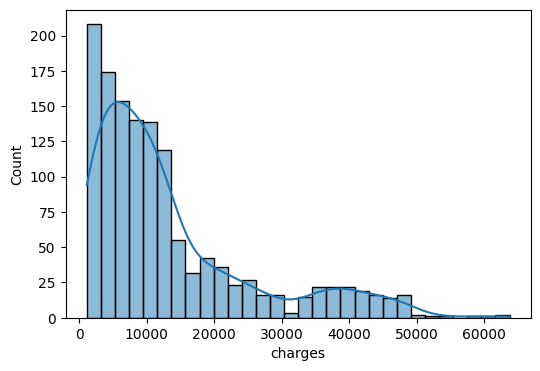

In [42]:
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], bins=30, kde=True)
plt.show()

## Initial Data Exploration Summary

At this stage, the dataset has been successfully loaded and inspected. The data consists of 1338 observations and 7 variables, including both numerical and categorical features. No missing values were detected, indicating that the dataset is clean and ready for further analysis.

The statistical summary revealed that numerical variables have varying ranges and distributions. In particular, the target variable (charges) shows a wide range of values, suggesting high variability in insurance costs among individuals.

Categorical variables such as sex, smoker, and region contain a limited number of categories and appear suitable for encoding in later stages.

Overall, the dataset structure is consistent, and no immediate data quality issues were observed. This provides a solid foundation for further exploratory analysis, including skewness and outlier detection.

In [43]:
df["charges"].skew()

np.float64(1.5158796580240388)

## Skewness Analysis

The skewness value of the target variable (charges) is approximately 1.51, indicating a strong positive skew. This confirms that the distribution is not symmetric and is heavily influenced by higher values.

Such skewness suggests that a transformation may be required in later stages to improve model performance, particularly for models sensitive to distribution assumptions.

In [44]:
for col in ["age", "bmi", "children"]:
    print(col, df[col].skew())

age 0.05567251565299186
bmi 0.2840471105987448
children 0.9383804401702414


## Skewness of Numerical Features

The skewness of numerical features was examined to understand their distribution characteristics. The variables age and BMI show low skewness and are relatively close to a normal distribution.

The variable children shows moderate skewness, which is expected due to its discrete nature.

However, the target variable (charges) exhibits strong positive skewness compared to other features, making it the primary candidate for transformation in later stages.

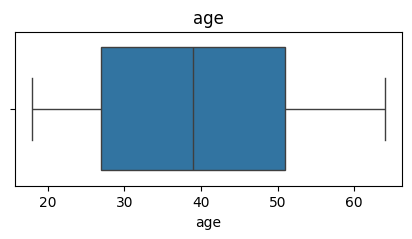

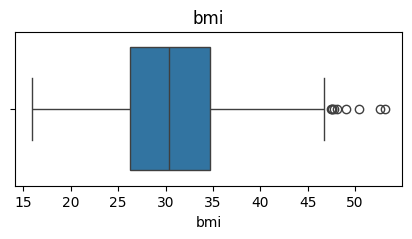

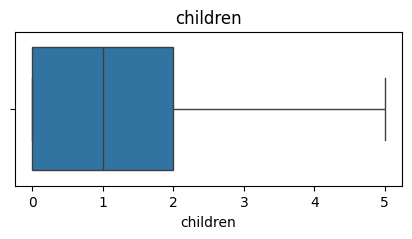

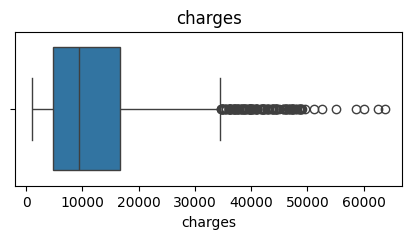

In [45]:
for col in ["age", "bmi", "children", "charges"]:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Outlier Analysis

Boxplot analysis was used to visually detect outliers in numerical variables. The variables age and children do not show significant outliers and appear to have stable distributions.

The BMI variable shows a few high-value outliers, indicating the presence of individuals with unusually high body mass index values.

The target variable (charges) exhibits a large number of outliers on the upper end. These extreme values correspond to individuals with very high medical costs and are consistent with the previously observed right-skewed distribution.

In [46]:
for col in ["age", "bmi", "children", "charges"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, "outlier %:", round(len(outliers)/len(df)*100, 2))

age outlier %: 0.0
bmi outlier %: 0.67
children outlier %: 0.0
charges outlier %: 10.39


## Outlier Ratio Analysis

Outliers were quantified using the IQR method. The variables age and children do not contain outliers, while BMI shows a very small percentage of outliers (0.67%), which is not considered significant.

However, the target variable (charges) contains approximately 10.39% outliers, indicating a substantial presence of extreme values. These high-cost observations play a significant role in shaping the distribution and must be carefully considered during the modeling phase.

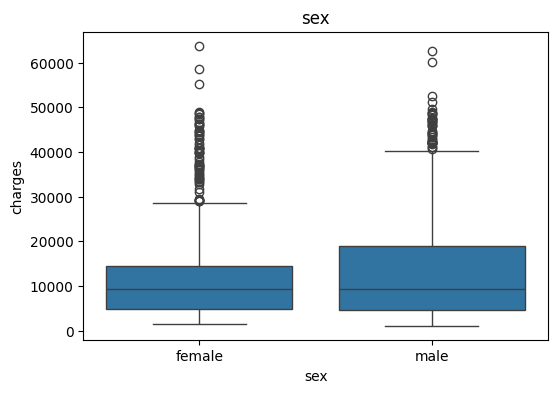

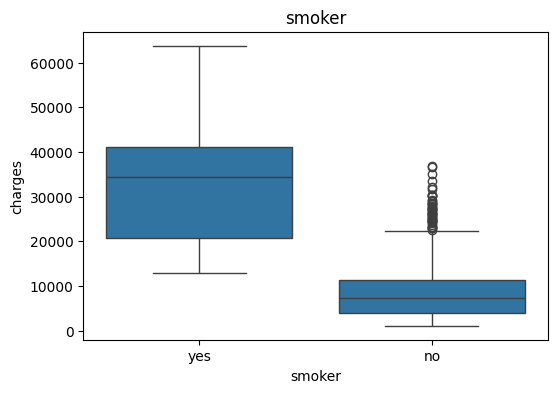

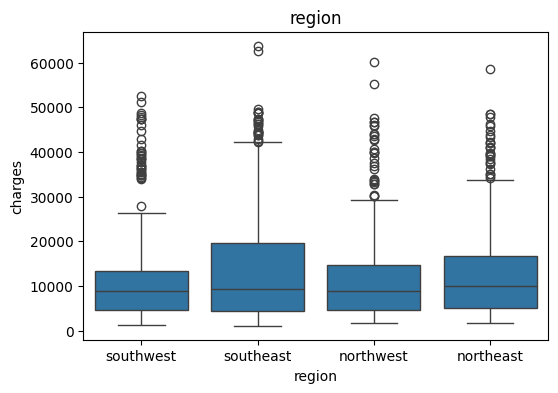

In [47]:
for col in ["sex", "smoker", "region"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df["charges"])
    plt.title(col)
    plt.show()

## Categorical Variables vs Target

The relationship between categorical variables and the target variable (charges) was analyzed using boxplots.

The variable sex does not show a significant difference in insurance costs between males and females.

In contrast, the variable smoker has a strong impact on charges. Individuals who smoke have substantially higher insurance costs compared to non-smokers, indicating that smoking is a major risk factor.

The region variable shows some variation across categories, but the differences are not as pronounced as those observed for smoking status.

In [48]:
X = df.drop("charges", axis=1)
y = df["charges"]


X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [49]:
X = df.drop("charges", axis=1).copy()
y = df["charges"]

X["bmi_age"] = X["bmi"] * X["age"]
X["smoker_bmi"] = X["bmi"] * (X["smoker"] == "yes").astype(int)

X.head()

,age,sex,bmi,children,smoker,region,bmi_age,smoker_bmi
0,19,female,27.900,0,yes,southwest,530.100,27.9
1,18,male,33.770,1,no,southeast,607.860,0.0
2,28,male,33.000,3,no,southeast,924.000,0.0
3,33,male,22.705,0,no,northwest,749.265,0.0
4,32,male,28.880,0,no,northwest,924.160,0.0


## Feature Engineering and Target Separation

Before feature engineering, the target variable (charges) was separated from the dataset to prevent data leakage. Since the goal of the model is to predict insurance costs, the target variable must not be included among the input features.

After separating the target variable, new features were created to capture interactions between existing variables. The feature bmi_age represents the combined effect of age and body mass index, reflecting how health risks may increase when both factors are high.

Additionally, smoker_bmi was created to emphasize the impact of BMI specifically for smokers. Since smoking is a major risk factor, combining it with BMI helps the model better capture high-risk individuals.

These engineered features enhance the dataset by introducing more complex relationships, allowing the model to learn patterns that may not be captured by the original variables alone.

In [50]:
numeric_features = ["age", "bmi", "children", "bmi_age", "smoker_bmi"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, np.log1p(y), test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [52]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(0.2530350321887347, np.float64(0.40545546930801635), 0.8171068033641941)

## Model Evaluation with Feature Engineering

After introducing engineered features into the pipeline, the performance of the Linear Regression model improved. The R² score increased compared to the previous baseline, indicating that the model is able to explain more variance in the target variable.

Additionally, both MAE and RMSE values decreased, showing that prediction errors were reduced. This demonstrates that the newly created features contributed positively to capturing more complex relationships in the data.

Overall, feature engineering enhanced the model's predictive performance.

In [53]:

pipelines = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ])
}

In [54]:
results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.253035,0.405455,0.817107
1,Random Forest,0.193131,0.367606,0.849659
2,Gradient Boosting,0.188698,0.349544,0.864070


## Model Selection Justification

Although Gradient Boosting achieved the highest performance among the tested models, Random Forest was selected for hyperparameter tuning due to its stability and interpretability.

Random Forest already demonstrated strong performance and is generally more robust and easier to tune compared to Gradient Boosting. It also provides a good balance between model complexity and computational efficiency.

By optimizing Random Forest, it was possible to significantly improve its performance while maintaining a more controlled and understandable modeling process.

In [55]:

tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

print("Hyperparameter tuning başlıyor...")

grid_search = GridSearchCV(
    tune_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Optimizasyon tamamlandı!")
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi CV RMSE:", -grid_search.best_score_)

final_pipeline = grid_search.best_estimator_

Hyperparameter tuning başlıyor...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Optimizasyon tamamlandı!
En iyi parametreler: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
En iyi CV RMSE: 0.3949996798905091


## Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV to improve the performance of the Random Forest model. Different combinations of parameters such as the number of trees, tree depth, and minimum samples per split were evaluated.

The best configuration resulted in a lower RMSE compared to the default model, indicating improved predictive performance. The selected parameters help balance model complexity and generalization, reducing the risk of overfitting while maintaining accuracy.

The optimized model was then selected as the final pipeline for further evaluation.

In [56]:

y_pred = final_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("FINAL MODEL SONUÇLARI")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.4f}")

FINAL MODEL SONUÇLARI
MAE : 0.190
RMSE: 0.358
R2  : 0.8573


## Final Model Results

The final model achieved strong performance on the test set, with an RMSE of approximately 0.358 and an R² score of 0.857. This indicates that the model is able to explain around 86% of the variance in insurance charges.

The MAE value of 0.190 shows that the average prediction error is relatively low, suggesting that the model produces accurate estimates.

Overall, the model demonstrates good predictive performance and generalization ability, making it suitable for estimating insurance costs based on the given features.

## Conclusion

In this project, a machine learning model was developed to predict medical insurance charges based on demographic and health-related factors. The analysis began with exploratory data analysis, where key patterns such as skewness and the impact of variables like smoking were identified.

Different models were tested and compared, including Linear Regression, Random Forest, and Gradient Boosting. The results showed that tree-based models performed better, indicating that the relationships in the dataset are not purely linear.

Feature engineering and hyperparameter tuning further improved the model performance. The final optimized Random Forest model achieved strong results, demonstrating good accuracy and generalization ability.

Overall, this project provided practical experience in building an end-to-end machine learning pipeline, including data preprocessing, feature engineering, model selection, evaluation, and optimization. It also highlighted the importance of understanding data characteristics and choosing appropriate modeling techniques accordingly.

## Practical Implications and Use Cases

The results of this project demonstrate that medical insurance charges can be predicted with a high level of accuracy using demographic and health-related variables. This has several important real-world applications.

For insurance companies, the model can be used to estimate the expected cost of a customer before offering a policy. This helps in risk assessment and allows companies to set more accurate and fair pricing strategies. High-risk individuals, such as smokers with high BMI, can be identified more effectively.

From a business perspective, the model can support decision-making by improving cost forecasting and financial planning. It can also be integrated into digital systems, such as online insurance calculators, where users receive instant premium estimates based on their personal information.

Additionally, the model can be used for customer segmentation, helping companies group individuals based on risk levels and design targeted products or policies.

Overall, this project shows how machine learning can be applied to solve a real-world business problem by transforming data into actionable insights and improving operational efficiency.